# **Ejercicio 6 - Parquet versus tablas DuckDB**

En este ejercicio se comparan dos estrategias para consultar los datos: leer directamente los archivos Parquet y materializarlos en una tabla dentro de una base de datos DuckDB. La lógica del benchmark se encuentra en [`../scripts/benchmark.py`](../scripts/benchmark.py), de tal forma que puede reproducirse también desde la línea de comandos.

In [1]:
import sys
from pathlib import Path

import duckdb
import pandas as pd

sys.path.insert(0, str(Path("../scripts").resolve()))
import benchmark as bm

ANIOS = bm.anios_descargados()
print(f"Años descargados: {ANIOS}")
print(f"Base de datos   : {bm.RUTA_DB.relative_to(bm.RAIZ)}")

# Conexión con límite de memoria (2 GB): el contenedor comparte la RAM con Metabase.
# La tabla se crea con CREATE OR REPLACE, por lo que cada ejecución parte de cero.
con = bm.conectar()

Años descargados: [2024, 2026]
Base de datos   : data/processed/taxis.duckdb


## **6.1 Consulta directa sobre los archivos Parquet**

Para consultar directamente los archivos Parquet se creó la vista `viajes_parquet`, que lee los 40 archivos descargados de 2024 y 2026 sin copiarlos y agrega las mismas columnas derivadas del Ejercicio 4 (tipo de taxi, mes del archivo y fechas unificadas). Por ejemplo, la siguiente consulta obtiene los viajes por año y tipo de taxi, considerando solo los viajes dentro del mes de su archivo: en 2024 se tienen 41.2 millones de viajes amarillos y 660 mil verdes, y en 2026, 29.7 millones y 337 mil, respectivamente.

In [2]:
bm.crear_vista_parquet(con, ANIOS)  # vista viajes_parquet: no copia datos, solo guarda la consulta

con.sql("""
    SELECT year(pickup) AS anio,
           tipo,
           COUNT(*)     AS viajes
    FROM viajes_parquet
    WHERE strftime(pickup, '%Y-%m') = mes_archivo
    GROUP BY anio, tipo
    ORDER BY anio, tipo DESC
""").df()

,anio,tipo,viajes
0,2024,yellow,41169300
1,2024,green,660054
2,2026,yellow,29703209
3,2026,green,337016


## **6.2 Creación de la tabla materializada**

Se creó la tabla `viajes_tabla` dentro de la base de datos `data/processed/taxis.duckdb` a partir de los años descargados (2024 y 2026), con las mismas columnas que la vista `viajes_parquet`. La creación tomó 35.8 segundos y la tabla contiene 71,870,407 registros. Cabe mencionar que la tabla ocupa 2,600 MB, más del doble que los archivos Parquet originales (1,172 MB), ya que Parquet comprime los datos de forma más agresiva y la tabla guarda además las columnas derivadas ya calculadas. Al estar dentro de `data/processed/`, esta base de datos no se versiona en Git.

In [3]:
segundos_materializacion = bm.materializar(con, ANIOS)

registros_tabla = con.execute("SELECT COUNT(*) FROM viajes_tabla").fetchone()[0]
# Bloques ocupados por la tabla: el archivo .duckdb puede conservar espacio libre de ejecuciones anteriores
tamanio_db = con.execute("SELECT used_blocks * block_size FROM pragma_database_size()").fetchone()[0]
tamanio_parquet = sum(p.stat().st_size for anio in ANIOS for p in bm.DIR_RAW.glob(f"*/{anio}/*.parquet"))

pd.DataFrame([{
    "registros": registros_tabla,
    "tiempo_creacion_s": round(segundos_materializacion, 1),
    "tamanio_parquet_mb": round(tamanio_parquet / 1024 ** 2),
    "tamanio_tabla_mb": round(tamanio_db / 1024 ** 2),
}])

,registros,tiempo_creacion_s,tamanio_parquet_mb,tamanio_tabla_mb
0,71870407,35.8,1172,2600


## **6.3 Consultas representativas**

Se seleccionaron ocho consultas a partir de las preguntas del Ejercicio 4, buscando cubrir distintos tipos de operación: un conteo simple, agregaciones por periodo de tiempo, agregaciones con filtros y cálculo de percentiles. Todas, excepto la C1, aplican el mismo filtro de viajes válidos de la vista `viajes_limpios`.

| Consulta | Pregunta | Tipo de operación |
|---|---|---|
| C1 - Conteo total de viajes | - | Conteo sin filtros |
| C2 - Viajes por mes y tipo | P1 | Agregación por mes y tipo |
| C3 - Viajes por hora del día | P2 | Agregación por hora |
| C4 - Distancia y duración mediana por mes | P3 | Percentiles por mes |
| C5 - Percentiles del monto por tipo | P6 | Percentiles por tipo |
| C6 - Formas de pago por tipo | P7 | Agregación por categoría |
| C7 - Propina promedio con tarjeta por mes | P8 | Agregación con filtro adicional |
| C8 - Monto total cobrado por mes | P11 | Suma por mes |

En las consultas C4 y C5 se utilizó `approx_quantile` en lugar de `MEDIAN` o `quantile_cont`, ya que estas últimas guardan todos los valores en memoria y, con los dos años, agotaban la memoria del contenedor. A continuación se muestra el SQL de cada consulta, donde la fuente (`viajes_parquet` o `viajes_tabla`) es lo único que cambia entre ambas estrategias.

In [4]:
for nombre, plantilla in bm.CONSULTAS.items():
    print(f"-- {nombre}")
    print(plantilla.format(fuente="viajes_tabla").strip())
    print()

-- C1 - Conteo total de viajes
SELECT COUNT(*) FROM viajes_tabla

-- C2 - Viajes por mes y tipo (P1)
SELECT strftime(pickup, '%Y-%m') AS mes, tipo, COUNT(*) AS viajes
        FROM viajes_tabla
        WHERE 
    strftime(pickup, '%Y-%m') = mes_archivo
    AND dropoff > pickup AND dropoff - pickup <= INTERVAL 24 HOUR
    AND trip_distance > 0 AND trip_distance <= 100
    AND fare_amount >= 0 AND total_amount > 0

        GROUP BY mes, tipo
        ORDER BY mes, tipo

-- C3 - Viajes por hora del dia (P2)
SELECT hour(pickup) AS hora, COUNT(*) AS viajes
        FROM viajes_tabla
        WHERE 
    strftime(pickup, '%Y-%m') = mes_archivo
    AND dropoff > pickup AND dropoff - pickup <= INTERVAL 24 HOUR
    AND trip_distance > 0 AND trip_distance <= 100
    AND fare_amount >= 0 AND total_amount > 0

        GROUP BY hora
        ORDER BY hora

-- C4 - Distancia y duracion mediana por mes (P3)
SELECT strftime(pickup, '%Y-%m') AS mes,
               approx_quantile(trip_distance, 0.5) AS dista

## **6.4 y 6.5 Ejecución de las consultas y tiempos de ejecución**

Cada consulta se ejecutó con el mismo texto SQL sobre ambas fuentes, cambiando únicamente la fuente, desde la misma conexión y con la misma configuración de DuckDB. Para cada una se hizo una ejecución de calentamiento que no se mide y luego tres ejecuciones, de las cuales se reporta la mediana del tiempo.

Como se esperaba, la tabla materializada fue más rápida en todas las consultas, entre 1.7 y 3.8 veces más rápida. La mayor diferencia se dio en las agregaciones con filtros y por categoría, como la propina con tarjeta (C7, de 9.8 a 2.6 segundos) o las formas de pago (C6, de 6.9 a 2.4 segundos), ya que en estas el tiempo de la consulta sobre Parquet se va principalmente en leer y descomprimir los 40 archivos y en calcular las columnas derivadas, mientras que la tabla ya las tiene almacenadas en el formato nativo de DuckDB. En cambio, la menor diferencia se dio en las medianas por mes (C4, 1.7 veces), donde el costo principal es el cálculo y no la lectura. Por otro lado, el conteo total (C1) es casi inmediato en ambas estrategias, ya que DuckDB obtiene la cantidad de registros de los metadatos sin recorrer los datos.

En conjunto, las ocho consultas toman 57.2 segundos sobre Parquet y 24.7 segundos sobre la tabla, es decir, se ahorran 32.5 segundos por cada ejecución del conjunto. Considerando que crear la tabla tomó 35.8 segundos, este costo se recupera después de ejecutar el conjunto de consultas un poco más de una vez.

In [5]:
resultados = bm.ejecutar_benchmark(con)
resultados

  C1 - Conteo total de viajes                        parquet   0.053 s   tabla   0.010 s


  C2 - Viajes por mes y tipo (P1)                    parquet   7.275 s   tabla   3.528 s


  C3 - Viajes por hora del dia (P2)                  parquet   6.508 s   tabla   2.419 s


  C4 - Distancia y duracion mediana por mes (P3)     parquet  11.009 s   tabla   6.336 s


  C5 - Percentiles del monto por tipo (P6)           parquet   7.487 s   tabla   3.653 s


  C6 - Formas de pago por tipo (P7)                  parquet   6.890 s   tabla   2.350 s


  C7 - Propina promedio con tarjeta por mes (P8)     parquet   9.799 s   tabla   2.589 s


  C8 - Monto total cobrado por mes (P11)             parquet   8.196 s   tabla   3.793 s


,consulta,tiempo_parquet_s,tiempo_tabla_s,aceleracion_tabla
0,C1 - Conteo total de viajes,0.053,0.010,5.22
1,C2 - Viajes por mes y tipo (P1),7.275,3.528,2.06
2,C3 - Viajes por hora del dia (P2),6.508,2.419,2.69
3,C4 - Distancia y duracion mediana por mes (P3),11.009,6.336,1.74
4,C5 - Percentiles del monto por tipo (P6),7.487,3.653,2.05
5,C6 - Formas de pago por tipo (P7),6.890,2.350,2.93
6,C7 - Propina promedio con tarjeta por mes (P8),9.799,2.589,3.78
7,C8 - Monto total cobrado por mes (P11),8.196,3.793,2.16


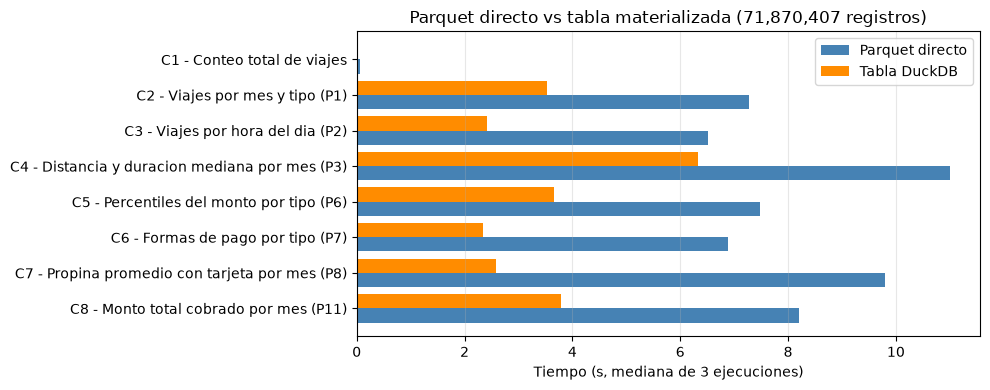

In [6]:
import matplotlib.pyplot as plt

fig, eje = plt.subplots(figsize=(10, 4))
posiciones = range(len(resultados))
eje.barh([p + 0.2 for p in posiciones], resultados["tiempo_parquet_s"], height=0.4, label="Parquet directo", color="steelblue")
eje.barh([p - 0.2 for p in posiciones], resultados["tiempo_tabla_s"], height=0.4, label="Tabla DuckDB", color="darkorange")
eje.set_yticks(list(posiciones))
eje.set_yticklabels(resultados["consulta"])
eje.invert_yaxis()
eje.set_xlabel("Tiempo (s, mediana de 3 ejecuciones)")
eje.set_title(f"Parquet directo vs tabla materializada ({registros_tabla:,} registros)")
eje.legend()
eje.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## **6.6 y 6.7 Benchmark con diferentes cantidades de datos y organización de los resultados**

Para observar cómo cambia el comportamiento con la cantidad de datos, se repitió el benchmark en tres escenarios: solo 2026 (30.0 millones de registros), solo 2024 (41.8 millones) y ambos años juntos (71.9 millones). Para cada año se creó su propia vista y su propia tabla, mientras que el escenario combinado reutiliza los resultados del 6.4. Los resultados se organizan en dos tablas: un resumen con el tiempo total de las ocho consultas por escenario y el detalle de cada consulta; además, se guardan en [`../docs/benchmark_resultados.csv`](../docs/benchmark_resultados.csv).

En los tres escenarios la tabla fue alrededor de 2.2 veces más rápida, y el tiempo de ambas estrategias crece de forma aproximadamente proporcional a la cantidad de registros: la tabla pasa de 9.7 a 13.7 y 24.7 segundos, y Parquet de 21.1 a 29.6 y 57.2 segundos. Asimismo, el costo de crear la tabla se recupera en todos los casos después de entre 1.1 y 1.5 ejecuciones del conjunto de consultas.

Lo único que se sale del comportamiento esperado es que, con ambos años juntos, Parquet tardó 57.2 segundos, más que la suma de cada año por separado (50.7 segundos), mientras que la tabla se mantuvo prácticamente igual a la suma (24.7 contra 23.4 segundos). Esta diferencia se concentra en la consulta de propinas (C7), que tardó 9.8 segundos contra 6.1 de la suma de ambos años y que en una ejecución previa del mismo notebook había tardado 5.9 segundos, por lo que considero que se debe a variabilidad entre ejecuciones y al límite de memoria de 2 GB, más que a un cambio real en el comportamiento.

In [7]:
# Cada año por separado; el escenario combinado reutiliza los resultados del 6.4
escenarios = [bm.ejecutar_escenario(con, [anio]) for anio in ANIOS]

combinado = resultados.copy()
combinado.insert(0, "escenario", "_".join(map(str, ANIOS)))
combinado.insert(1, "registros", registros_tabla)
combinado.insert(2, "creacion_tabla_s", round(segundos_materializacion, 1))

benchmark = (pd.concat(escenarios + [combinado], ignore_index=True)
               .sort_values(["registros", "consulta"], ignore_index=True))
benchmark.to_csv("../docs/benchmark_resultados.csv", index=False)
print("Resultados guardados en docs/benchmark_resultados.csv")

Escenario 2024: 41,829,938 registros, tabla creada en 23.9 s
  C1 - Conteo total de viajes                        parquet   0.020 s   tabla   0.003 s


  C2 - Viajes por mes y tipo (P1)                    parquet   4.046 s   tabla   1.880 s


  C3 - Viajes por hora del dia (P2)                  parquet   3.466 s   tabla   1.238 s


  C4 - Distancia y duracion mediana por mes (P3)     parquet   6.013 s   tabla   3.731 s


  C5 - Percentiles del monto por tipo (P6)           parquet   4.548 s   tabla   2.099 s


...

  C4 - Distancia y duracion mediana por mes (P3)     parquet   4.391 s   tabla   2.666 s


  C5 - Percentiles del monto por tipo (P6)           parquet   3.091 s   tabla   1.540 s


  C6 - Formas de pago por tipo (P7)                  parquet   2.573 s   tabla   0.970 s


  C7 - Propina promedio con tarjeta por mes (P8)     parquet   2.300 s   tabla   0.914 s


  C8 - Monto total cobrado por mes (P11)             parquet   3.022 s   tabla   1.354 s
Resultados guardados en docs/benchmark_resultados.csv


In [8]:
# Resumen por escenario: tiempo total de las ocho consultas con cada estrategia
resumen = (benchmark.groupby(["escenario", "registros", "creacion_tabla_s"], as_index=False)
                    [["tiempo_parquet_s", "tiempo_tabla_s"]].sum()
                    .sort_values("registros", ignore_index=True))
resumen["aceleracion_tabla"] = (resumen["tiempo_parquet_s"] / resumen["tiempo_tabla_s"]).round(2)
resumen["ahorro_por_ejecucion_s"] = (resumen["tiempo_parquet_s"] - resumen["tiempo_tabla_s"]).round(1)
resumen["ejecuciones_para_recuperar_creacion"] = (resumen["creacion_tabla_s"] / resumen["ahorro_por_ejecucion_s"]).round(2)
resumen.round(2)

,escenario,registros,creacion_tabla_s,tiempo_parquet_s,tiempo_tabla_s,aceleracion_tabla,ahorro_por_ejecucion_s,ejecuciones_para_recuperar_creacion
0,2026,30040469,17.4,21.11,9.73,2.17,11.4,1.53
1,2024,41829938,23.9,29.55,13.65,2.16,15.9,1.50
2,2024_2026,71870407,35.8,57.22,24.68,2.32,32.5,1.10


In [9]:
# Detalle por consulta: tiempo en segundos de cada estrategia en cada escenario
detalle = benchmark.pivot_table(index="consulta", columns="escenario",
                                values=["tiempo_parquet_s", "tiempo_tabla_s"])
detalle = detalle.reindex(columns=resumen["escenario"], level=1)
detalle.columns = [f"{estrategia.replace('tiempo_', '').replace('_s', '')} {escenario}"
                   for estrategia, escenario in detalle.columns]
detalle

,parquet 2026,parquet 2024,parquet 2024_2026,tabla 2026,tabla 2024,tabla 2024_2026
consulta,,,,,,
C1 - Conteo total de viajes,0.015,0.020,0.053,0.002,0.003,0.010
C2 - Viajes por mes y tipo (P1),3.149,4.046,7.275,1.369,1.880,3.528
C3 - Viajes por hora del dia (P2),2.568,3.466,6.508,0.914,1.238,2.419
C4 - Distancia y duracion mediana por mes (P3),4.391,6.013,11.009,2.666,3.731,6.336
C5 - Percentiles del monto por tipo (P6),3.091,4.548,7.487,1.540,2.099,3.653
C6 - Formas de pago por tipo (P7),2.573,3.463,6.890,0.970,1.303,2.350
C7 - Propina promedio con tarjeta por mes (P8),2.300,3.796,9.799,0.914,1.516,2.589
C8 - Monto total cobrado por mes (P11),3.022,4.195,8.196,1.354,1.882,3.793


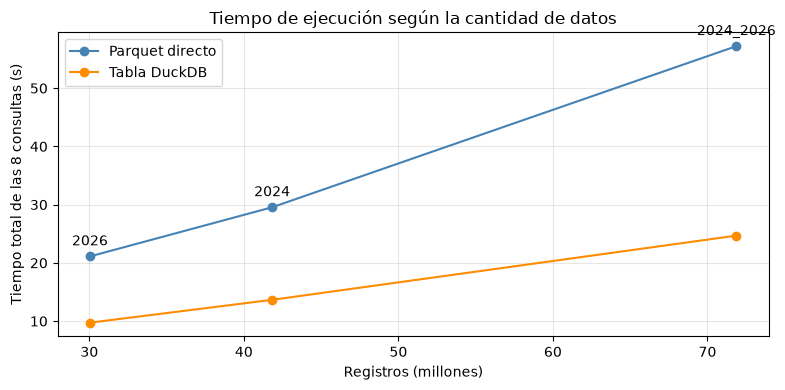

In [10]:
fig, eje = plt.subplots(figsize=(8, 4))
millones = resumen["registros"] / 1e6
eje.plot(millones, resumen["tiempo_parquet_s"], marker="o", color="steelblue", label="Parquet directo")
eje.plot(millones, resumen["tiempo_tabla_s"], marker="o", color="darkorange", label="Tabla DuckDB")
for x, y, etiqueta in zip(millones, resumen["tiempo_parquet_s"], resumen["escenario"]):
    eje.annotate(etiqueta, (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
eje.set_xlabel("Registros (millones)")
eje.set_ylabel("Tiempo total de las 8 consultas (s)")
eje.set_title("Tiempo de ejecución según la cantidad de datos")
eje.legend()
eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **6.8 Consultas utilizadas en el benchmark**

Como se mencionó en el 6.3, para el benchmark se seleccionaron algunas de las consultas utilizadas para responder las preguntas planteadas en el Ejercicio 4. El SQL completo de cada una se muestra en la celda del 6.3 y se encuentra definido en `CONSULTAS` dentro de [`../scripts/benchmark.py`](../scripts/benchmark.py), por lo que el benchmark puede reproducirse con `python scripts/benchmark.py --anio <años>`. Las consultas fueron:

- **C1 - Conteo total de viajes:** cantidad de registros de la fuente, sin filtros.
- **C2 - Viajes por mes y tipo (P1):** evolución mensual de la cantidad de viajes de amarillos y verdes.
- **C3 - Viajes por hora del día (P2):** concentración de la demanda según la hora.
- **C4 - Distancia y duración mediana por mes (P3):** viaje típico de cada mes.
- **C5 - Percentiles del monto por tipo (P6):** comparación de los montos entre amarillos y verdes.
- **C6 - Formas de pago por tipo (P7):** distribución de las formas de pago.
- **C7 - Propina promedio con tarjeta por mes (P8):** evolución de la propina en pagos con tarjeta.
- **C8 - Monto total cobrado por mes (P11):** monto total generado en cada mes.

## **6.9 Análisis de los resultados**

Ambas estrategias logran tiempos de pocos segundos sobre 72 millones de registros porque DuckDB es un motor orientado a cargas analíticas (OLAP). En lugar de cargar todo el conjunto de datos en la memoria RAM, como ocurriría con pandas, DuckDB lee únicamente las columnas que necesita cada consulta, las procesa por lotes y en paralelo, y solo devuelve a Python el resultado final, que ya viene agregado. Es decir, Python únicamente envía la consulta y recibe la respuesta, mientras que todo el procesamiento lo hace el motor de DuckDB dentro del mismo proceso. Por ejemplo, la consulta de formas de pago solo necesita las columnas de tipo, forma de pago y las del filtro de limpieza, por lo que el resto de columnas nunca se lee.

La diferencia a favor de la tabla se explica por el trabajo que se repite en cada consulta sobre Parquet: abrir los 40 archivos, leer sus metadatos, descomprimir las columnas y calcular las columnas derivadas, como el tipo de taxi a partir del nombre del archivo o las fechas unificadas. La tabla hace todo este trabajo una sola vez al crearse y guarda los datos en el formato nativo de DuckDB, por lo que las consultas posteriores solo leen y calculan. Es por esto que la ganancia es mayor en las consultas donde el costo principal es la lectura (agregaciones simples y con filtros) y menor en las que el costo principal es el cálculo, como las medianas y percentiles.

No obstante, la tabla tiene costos: ocupa más del doble de espacio en disco que los Parquet, su creación toma tiempo y requiere memoria, y es una copia que queda desactualizada cuando llegan nuevos archivos, por lo que debe volver a crearse. Además, durante el benchmark se observó que DuckDB requiere cuidado con la memoria: con todos los registros, funciones como `MEDIAN` guardan todos los valores y agotaban la memoria del contenedor, por lo que fue necesario limitar la memoria de DuckDB y utilizar percentiles aproximados.

## **6.10 Cuándo consultar Parquet y cuándo materializar una tabla**

Para empezar, considero importante distinguir el tipo de carga de trabajo. En aplicaciones cliente-servidor, como un CRUD o un sistema de inventario, se realizan consultas sencillas que leen o modifican pocos registros completos, lo cual corresponde a una carga transaccional (OLTP) y es donde funcionan bien bases de datos como PostgreSQL. En cambio, en este laboratorio el trabajo es analítico (OLAP): se recorren millones de registros, pero solo se utilizan unas pocas columnas para calcular agregaciones, y es ahí donde DuckDB se destaca, sin importar si consulta los Parquet o una tabla.

Dentro de DuckDB, la decisión entre ambas estrategias depende principalmente de qué tan seguido se consultan los datos y qué tan seguido cambian. Consultar directamente los archivos Parquet me parece apropiado cuando se está explorando un conjunto de datos, cuando se harán pocas consultas, cuando llegan archivos nuevos con frecuencia o cuando el espacio en disco es limitado, ya que no tiene costo de preparación, ocupa menos espacio y siempre refleja los archivos más recientes. Por ejemplo, en este laboratorio, donde se incorporan años de forma incremental, consultar los Parquet permitió que las consultas incluyeran 2024 sin ningún paso adicional.

Por otro lado, materializar una tabla conviene cuando las mismas consultas se ejecutan muchas veces sobre datos que cambian poco. Por ejemplo, un tablero en Metabase que se actualiza cada vez que alguien lo abre, sobre datos que la TLC publica una vez al mes: en este caso, según el benchmark, el costo de crear la tabla se recupera después de ejecutar las consultas un poco más de una vez, por lo que conviene recrearla después de cada descarga y consultar la tabla el resto del tiempo.

In [11]:
con.close()  # libera el archivo